# Distance-residual PINN for a scalar differential inclusion

This notebook implements a **Physics-Informed Neural Network** based on a distance residual for a scalar differential inclusion.

The problem is

$$
\dot x(t) \in F(x(t)), \qquad x(0)=0, \qquad t\in[0,1],
$$

where

$$
F(x)=[-x-1,-x+1].
$$

We also impose the terminal condition

$$
x(1)=0.5.
$$

The central idea is to replace the classical ODE residual by the distance between the learned velocity and the admissible set of velocities.


## 1. Imports and configuration

We start by importing the required libraries. We will use:

- `TensorFlow/Keras` to build and train the neural network.
- `GradientTape` to compute derivatives by automatic differentiation.
- `NumPy` for numerical operations.
- `Matplotlib` to visualize the results.
- A `Config` class to collect the hyperparameters of the experiment.


In [71]:
import os
import math
from dataclasses import dataclass

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

In [72]:
@dataclass
class Config:
    seed: int = 1234
    n_collocation: int = 256
    n_test: int = 1000
    width: int = 32
    depth: int = 3
    lr: float = 1e-3
    epochs: int = 5000
    lambda_terminal: float = 10.0
    terminal_value: float = 0.5
    output_dir: str = "../results/results_tf_distance_residual_pinn"


def set_seed(seed: int):
    np.random.seed(seed)
    tf.random.set_seed(seed)

## 2. The differential inclusion

The inclusion is

$$
\dot x(t) \in [-x(t)-1,-x(t)+1].
$$

Equivalently, it can be written as

$$
\dot x(t)=-x(t)+u(t), \qquad u(t)\in[-1,1].
$$

Therefore, given a candidate trajectory $x_\theta(t)$, the reconstructed implicit control is

$$
u_\theta(t)=\dot x_\theta(t)+x_\theta(t).
$$

The trajectory is admissible whenever

$$
u_\theta(t)\in[-1,1]
$$

for almost every $t$.


## 3. Known reference solution

For comparison, we use a known feasible solution of the form

$$
x_*(t)=u_*(1-e^{-t}),
$$

where $u_*$ is constant. To impose $x_*(1)=0.5$, we take

$$
u_* = \frac{0.5}{1-e^{-1}}.
$$

Since $u_*$ belongs to $[-1,1]$, this trajectory is admissible for the inclusion.


In [73]:
def exact_solution(t: np.ndarray, terminal_value: float = 0.5):
    u_star = terminal_value / (1.0 - math.exp(-1.0))
    x_star = u_star * (1.0 - np.exp(-t))
    return x_star, u_star

## 4. Base neural network

We build a fully connected neural network with `tanh` activation. This network represents an auxiliary function $N_\theta(t)$.

We then construct the trial solution as

$$
x_\theta(t)=tN_\theta(t),
$$

which enforces the initial condition $x_\theta(0)=0$ exactly.


In [74]:
def build_base_network(width: int = 32, depth: int = 3) -> tf.keras.Model:
    inputs = tf.keras.Input(shape=(1,))
    z = inputs

    for _ in range(depth):
        z = tf.keras.layers.Dense(
            width,
            activation="tanh",
            kernel_initializer="glorot_normal",
            bias_initializer="zeros",
        )(z)

    outputs = tf.keras.layers.Dense(
        1,
        activation=None,
        kernel_initializer="glorot_normal",
        bias_initializer="zeros",
    )(z)

    return tf.keras.Model(inputs=inputs, outputs=outputs)

## 5. Strong imposition of the initial condition

Instead of penalizing $x(0)=0$ in the loss function, we impose it directly through the parametrization

$$
x_\theta(t)=tN_\theta(t).
$$

Thus, independently of the network weights,

$$
x_\theta(0)=0.
$$


In [75]:
class TrialSolution(tf.keras.Model):
    """
    Hard imposition of x(0)=0 through

        x_theta(t) = t N_theta(t).
    """

    def __init__(self, width: int = 32, depth: int = 3):
        super().__init__()
        self.N = build_base_network(width=width, depth=depth)

    def call(self, t, training=False):
        return t * self.N(t, training=training)

## 6. Computing $x_\theta(t)$ and $\dot x_\theta(t)$

The key point of a PINN is that derivatives of the neural network are computed by automatic differentiation. Here we use `tf.GradientTape` to obtain

$$
\dot x_\theta(t)=\frac{d}{dt}x_\theta(t).
$$


In [76]:
def model_and_derivative(model: tf.keras.Model, t: tf.Tensor, training: bool = False):
    """
    Computes x_theta(t) and x_theta'(t) with automatic differentiation.
    """
    with tf.GradientTape() as tape:
        tape.watch(t)
        x = model(t, training=training)
    dx = tape.gradient(x, t)
    return x, dx

## 7. Distance residual for the inclusion

For an interval $[a,b]$, the distance from a scalar value $r$ to the interval is zero if $r\in[a,b]$, and positive if $r$ lies outside the interval.

In our case,

$$
a=-x_\theta(t)-1,
\qquad
b=-x_\theta(t)+1,
$$

and

$$
r=\dot x_\theta(t).
$$

The squared distance to $[a,b]$ can be written as

$$
\operatorname{dist}^2(r,[a,b])
=
\operatorname{ReLU}(a-r)^2+
\operatorname{ReLU}(r-b)^2.
$$

Therefore, if $\dot x_\theta(t)$ lies inside the admissible interval, the residual is zero. If it lies below $a$ or above $b$, the corresponding violation is penalized.


In [77]:
def distance_residual(model: tf.keras.Model, t: tf.Tensor, training: bool = False):
    """
    Computes the pointwise squared distance residual:

        dist^2(x_theta'(t), [-x_theta(t)-1, -x_theta(t)+1]).
    """
    x, dx = model_and_derivative(model, t, training=training)

    lower = -x - 1.0
    upper = -x + 1.0

    residual_sq = tf.nn.relu(lower - dx) ** 2 + tf.nn.relu(dx - upper) ** 2

    # Since x' = -x + u, the implicit control is u = x' + x.
    u_reconstructed = dx + x

    return residual_sq, x, dx, lower, upper, u_reconstructed

## 8. Loss function

The loss has two terms:

1. **Inclusion loss**, which penalizes violations of the condition $\dot x_\theta(t)\in F(x_\theta(t))$.
2. **Terminal loss**, which approximately imposes $x_\theta(1)=0.5$.

The total loss is

$$
\mathcal L(\theta)
=
\mathcal L_{\mathrm{incl}}(\theta)
+
\lambda_T\mathcal L_T(\theta).
$$

The initial condition does not appear as a loss term because it is already enforced exactly through $x_\theta(t)=tN_\theta(t)$.


In [78]:
def compute_loss(model: tf.keras.Model, t_col: tf.Tensor, cfg: Config):
    residual_sq, _, _, _, _, _ = distance_residual(model, t_col, training=True)

    t_terminal = tf.ones((1, 1), dtype=tf.float32)
    x_terminal = model(t_terminal, training=True)

    loss_inclusion = tf.reduce_mean(residual_sq)
    loss_terminal = tf.reduce_mean((x_terminal - cfg.terminal_value) ** 2)

    total_loss = loss_inclusion + cfg.lambda_terminal * loss_terminal
    return total_loss, loss_inclusion, loss_terminal

## 9. Training step

We define a compiled training step with `@tf.function` to speed up execution.

At each iteration:

1. The inclusion residual is evaluated at the collocation points.
2. The terminal error is computed.
3. The loss is differentiated with respect to the trainable weights.
4. The weights are updated using Adam.


In [79]:
@tf.function
def train_step(model, optimizer, t_col, lambda_terminal, terminal_value):
    """
    A compiled training step. The scalar parameters are passed explicitly
    so that TensorFlow does not need to trace over the dataclass.
    """
    with tf.GradientTape() as tape:
        residual_sq, _, _, _, _, _ = distance_residual(model, t_col, training=True)

        t_terminal = tf.ones((1, 1), dtype=tf.float32)
        x_terminal = model(t_terminal, training=True)

        loss_inclusion = tf.reduce_mean(residual_sq)
        loss_terminal = tf.reduce_mean((x_terminal - terminal_value) ** 2)
        total_loss = loss_inclusion + lambda_terminal * loss_terminal

    gradients = tape.gradient(total_loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    return total_loss, loss_inclusion, loss_terminal

## 10. Training loop

The collocation points are chosen uniformly in $[0,1]$. In a more general implementation, they could be sampled randomly or adaptively.

The training procedure stores three curves:

- total loss,
- inclusion loss,
- terminal loss.


In [80]:
def train(model: tf.keras.Model, cfg: Config):
    t_col = tf.linspace(0.0, 1.0, cfg.n_collocation)
    t_col = tf.reshape(t_col, (-1, 1))

    optimizer = tf.keras.optimizers.Adam(learning_rate=cfg.lr)

    history = {
        "loss_total": [],
        "loss_inclusion": [],
        "loss_terminal": [],
    }

    for epoch in range(1, cfg.epochs + 1):
        loss, loss_inclusion, loss_terminal = train_step(
            model,
            optimizer,
            t_col,
            tf.constant(cfg.lambda_terminal, dtype=tf.float32),
            tf.constant(cfg.terminal_value, dtype=tf.float32),
        )

        history["loss_total"].append(float(loss.numpy()))
        history["loss_inclusion"].append(float(loss_inclusion.numpy()))
        history["loss_terminal"].append(float(loss_terminal.numpy()))

        if epoch == 1 or epoch % 1000 == 0:
            print(
                f"Epoch {epoch:6d} | "
                f"loss={history['loss_total'][-1]:.3e} | "
                f"incl={history['loss_inclusion'][-1]:.3e} | "
                f"terminal={history['loss_terminal'][-1]:.3e}"
            )

    return history

## 11. Model evaluation

After training, we evaluate the model on a fine grid. We compute:

- the learned trajectory $x_\theta(t)$,
- the derivative $\dot x_\theta(t)$,
- the admissible band $[-x_\theta(t)-1,-x_\theta(t)+1]$,
- the implicit control $u_\theta(t)=\dot x_\theta(t)+x_\theta(t)$,
- the pointwise distance residual,
- the error with respect to the explicit reference solution.


In [81]:
def evaluate(model: tf.keras.Model, cfg: Config):
    t = tf.linspace(0.0, 1.0, cfg.n_test)
    t = tf.reshape(t, (-1, 1))

    residual_sq, x, dx, lower, upper, u = distance_residual(model, t, training=False)

    t_np = t.numpy().reshape(-1)
    x_np = x.numpy().reshape(-1)
    dx_np = dx.numpy().reshape(-1)
    lower_np = lower.numpy().reshape(-1)
    upper_np = upper.numpy().reshape(-1)
    u_np = u.numpy().reshape(-1)
    residual_np = residual_sq.numpy().reshape(-1)

    x_exact, u_star = exact_solution(t_np, cfg.terminal_value)

    metrics = {
        "mean_distance_residual": float(np.mean(residual_np)),
        "max_distance_residual": float(np.max(residual_np)),
        "terminal_error": float(abs(x_np[-1] - cfg.terminal_value)),
        "l2_error_exact": float(np.sqrt(np.mean((x_np - x_exact) ** 2))),
        "u_star_exact": float(u_star),
        "u_reconstructed_min": float(np.min(u_np)),
        "u_reconstructed_max": float(np.max(u_np)),
    }

    data = {
        "t": t_np,
        "x": x_np,
        "dx": dx_np,
        "lower": lower_np,
        "upper": upper_np,
        "u": u_np,
        "residual_sq": residual_np,
        "x_exact": x_exact,
        "u_star": u_star,
    }

    return data, metrics

## 12. Visualization and saving results

We generate several figures:

1. Comparison between $x_\theta(t)$ and the known solution $x_*(t)$.
2. Learned derivative versus the admissible velocity band.
3. Pointwise distance residual.
4. Reconstructed implicit control.
5. Training history.


In [82]:
def save_plots(data, history, cfg: Config):
    os.makedirs(cfg.output_dir, exist_ok=True)
    t = data["t"]

    plt.figure(figsize=(7, 4))
    plt.plot(t, data["x"], label=r"$x_\theta(t)$")
    plt.plot(t, data["x_exact"], "--", label=r"$x_*(t)$")
    plt.xlabel(r"$t$")
    plt.ylabel(r"$x(t)$")
    plt.title("State trajectory")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.output_dir, "state_vs_exact.png"), dpi=200)
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(t, data["dx"], label=r"$\dot{x}_\theta(t)$")
    plt.plot(t, data["lower"], "--", label=r"$-x_\theta(t)-1$")
    plt.plot(t, data["upper"], "--", label=r"$-x_\theta(t)+1$")
    plt.xlabel(r"$t$")
    plt.ylabel("velocity")
    plt.title("Derivative and admissible interval")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.output_dir, "derivative_admissible_band.png"), dpi=200)
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.semilogy(t, data["residual_sq"] + 1e-20)
    plt.xlabel(r"$t$")
    plt.ylabel(r"$\operatorname{dist}^2(\dot{x}_\theta(t),F(x_\theta(t)))$")
    plt.title("Pointwise squared distance residual")
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.output_dir, "pointwise_residual.png"), dpi=200)
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(t, data["u"], label=r"$u_\theta(t)=\dot{x}_\theta(t)+x_\theta(t)$")
    plt.axhline(1.0, linestyle="--", label=r"$u=1$")
    plt.axhline(-1.0, linestyle="--", label=r"$u=-1$")
    plt.axhline(data["u_star"], linestyle=":", label=rf"$u_*={data['u_star']:.3f}$")
    plt.xlabel(r"$t$")
    plt.ylabel(r"$u(t)$")
    plt.title("Reconstructed implicit control")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.output_dir, "reconstructed_control.png"), dpi=200)
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.semilogy(history["loss_total"], label="total")
    plt.semilogy(history["loss_inclusion"], label="inclusion")
    plt.semilogy(history["loss_terminal"], label="terminal")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title("Training history")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.output_dir, "training_history.png"), dpi=200)
    plt.show()

In [83]:
def save_metrics(metrics, cfg: Config):
    os.makedirs(cfg.output_dir, exist_ok=True)
    path = os.path.join(cfg.output_dir, "metrics.txt")

    with open(path, "w", encoding="utf-8") as f:
        for key, value in metrics.items():
            f.write(f"{key}: {value:.12e}\n")

    print("\nMetrics")
    print("-------")
    for key, value in metrics.items():
        print(f"{key}: {value:.12e}")

## 13. Running the experiment

This cell trains the model, evaluates the results, and saves the figures.

> Note: the default value is `epochs = 12000`, as in the original script. For a quick test, you may temporarily reduce it, for example to `epochs = 2000`.


Configuration
-------------
Config(seed=1234, n_collocation=256, n_test=1000, width=32, depth=3, lr=0.001, epochs=5000, lambda_terminal=10.0, terminal_value=0.5, output_dir='../results/results_tf_distance_residual_pinn')
Epoch      1 | loss=6.540e+00 | incl=0.000e+00 | terminal=6.540e-01
Epoch   1000 | loss=1.367e-04 | incl=1.304e-04 | terminal=6.299e-07
Epoch   2000 | loss=1.514e-06 | incl=1.494e-06 | terminal=2.066e-09
Epoch   3000 | loss=7.488e-08 | incl=7.448e-08 | terminal=4.030e-11
Epoch   4000 | loss=7.585e-09 | incl=7.574e-09 | terminal=1.151e-12
Epoch   5000 | loss=4.874e-10 | incl=4.869e-10 | terminal=5.684e-14


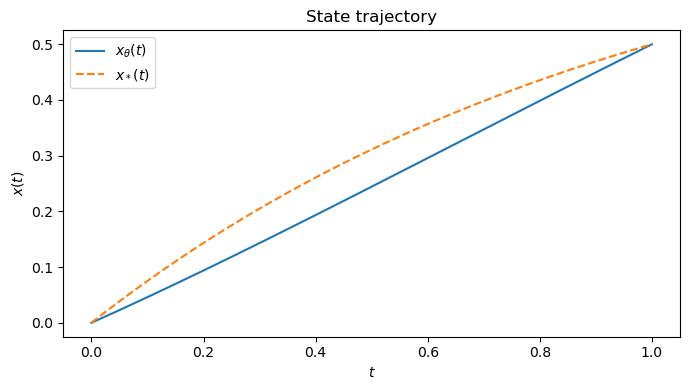

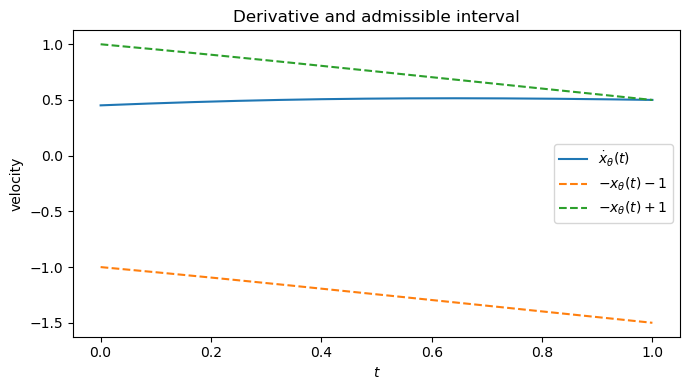

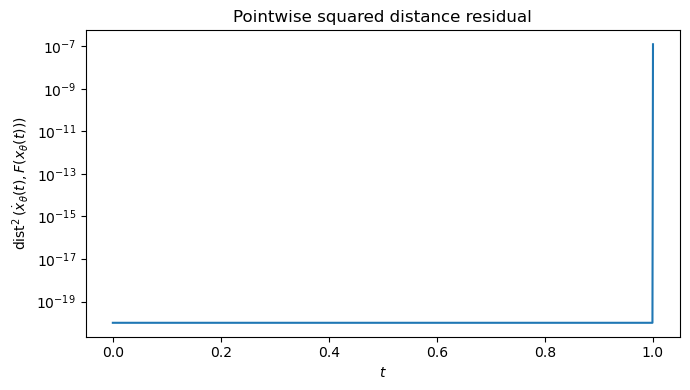

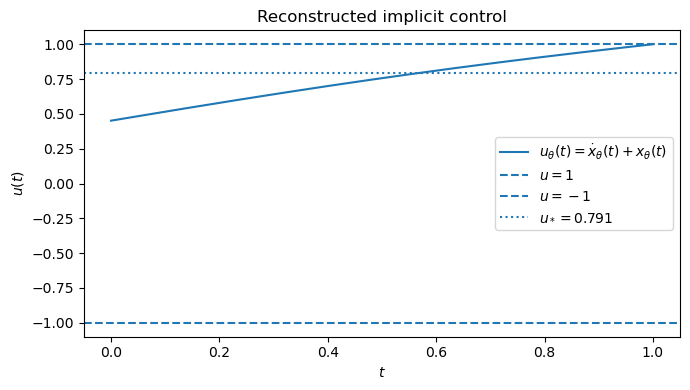

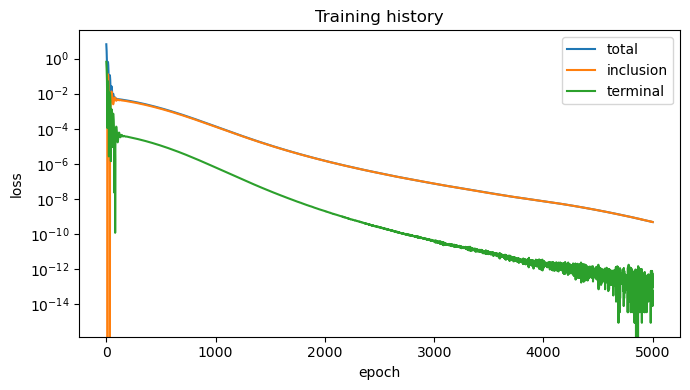


Metrics
-------
mean_distance_residual: 1.233348145835e-10
max_distance_residual: 1.233348143614e-07
terminal_error: 7.748603820801e-07
l2_error_exact: 4.918199777603e-02
u_star_exact: 7.909883534347e-01
u_reconstructed_min: 4.516347050667e-01
u_reconstructed_max: 1.000351190567e+00

Saved results in: ../results/results_tf_distance_residual_pinn


In [84]:
cfg = Config()
set_seed(cfg.seed)

os.makedirs(cfg.output_dir, exist_ok=True)

print("Configuration")
print("-------------")
print(cfg)

model = TrialSolution(width=cfg.width, depth=cfg.depth)

history = train(model, cfg)
data, metrics = evaluate(model, cfg)

save_plots(data, history, cfg)
save_metrics(metrics, cfg)

model.save_weights(os.path.join(cfg.output_dir, "model.weights.h5"))

print(f"\nSaved results in: {cfg.output_dir}")

## 14. Interpretation of the results

After training, we should observe the following:

- The learned trajectory $x_\theta(t)$ satisfies $x_\theta(0)=0$ exactly, by construction.
- The terminal condition $x_\theta(1)\approx 0.5$ is imposed through penalization.
- The derivative $\dot x_\theta(t)$ remains inside the admissible band

$$
[-x_\theta(t)-1,-x_\theta(t)+1].
$$

- The pointwise distance residual should be small.
- The reconstructed control

$$
u_\theta(t)=\dot x_\theta(t)+x_\theta(t)
$$

should remain inside the interval $[-1,1]$.

This example illustrates how a differential inclusion can be handled with a PINN without choosing in advance a particular single-valued selection of the multifunction $F$.
